# 06 · Long-run behaviour and mixing

Stationary distributions answer "where does the chain spend its time?", mean return and first-passage times
answer "how long until?", and mixing times answer "how soon does the starting point stop mattering?" - the
question every Markov chain Monte Carlo user must ask. This notebook computes all three, meets reversibility
and detailed balance, and closes with PageRank, the most widely used stationary distribution.

**What you will learn**
- compute stationary laws by solving, iterating and simulating
- compute mean return and first-passage times
- measure mixing by total variation and the spectral gap
- check reversibility and compute PageRank

**Before you start:** notebook 05  ·  **Time:** about 75 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engstoch import markov as mk, models
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Stationary distributions three ways

In [2]:
inv = models.inventory_chain(s=2, S=6, demand_mean=2.0)
c = inv["chain"]
pi = c.stationary()
pw = c.stationary_power()
print("end-of-week stock, stationary law:", pi.round(4).tolist())
print(f"power iteration: {pw['iterations']} iterations, max difference {np.max(np.abs(pw['pi'] - pi)):.1e}; |lambda_2| = {c.spectral_gap()['slem']:.3f}")
path = c.simulate(200_000, 6, R(1))
print("long-run fractions of a simulated path:", (np.bincount(path, minlength=7) / len(path)).round(4).tolist())
print(f"expected stock {np.dot(np.arange(7), pi):.3f}; probability of ending a week empty {pi[0]:.4f}")

end-of-week stock, stationary law: [0.1077, 0.1187, 0.174, 0.2016, 0.1903, 0.145, 0.0627]
power iteration: 23 iterations, max difference 1.1e-14; |lambda_2| = 0.276


long-run fractions of a simulated path: [0.1066, 0.12, 0.1742, 0.2025, 0.19, 0.1445, 0.0622]
expected stock 2.934; probability of ending a week empty 0.1077


The linear solve πP = π with Σπ = 1 is exact; power iteration converges at the rate |λ₂|; a long simulation
converges at the Monte Carlo rate. The stationary law turns the policy into numbers: average stock, stock-out
frequency and, with costs attached, the long-run cost per week - the basis for choosing s and S.

## Return times, first passages and Kemeny's constant

In [3]:
M = c.mean_first_passage()
print("mean return times (diagonal) vs 1/pi:", np.round(np.diag(M), 3).tolist(), np.round(1 / pi, 3).tolist())
print("mean weeks to first stock-out, from each starting stock:", np.round(M[:, 0], 2).tolist())
print(f"Kemeny's constant: {c.kemeny_constant():.4f};  sum_j pi_j m_ij for each i (j != i):", np.round([np.sum(pi * M[i]) - pi[i] * M[i, i] for i in range(7)], 4).tolist())

mean return times (diagonal) vs 1/pi: [9.287, 8.424, 5.746, 4.96, 5.254, 6.898, 15.956] [9.287, 8.424, 5.746, 4.96, 5.254, 6.898, 15.956]
mean weeks to first stock-out, from each starting stock: [9.29, 9.29, 9.29, 6.97, 8.18, 8.81, 9.29]
Kemeny's constant: 5.6583;  sum_j pi_j m_ij for each i (j != i): [5.6583, 5.6583, 5.6583, 5.6583, 5.6583, 5.6583, 5.6583]


Kac's formula says the mean return time to a state is 1/π_i - frequent states are revisited quickly. Mean
first-passage times come from the fundamental matrix Z = (I − P + 1π)⁻¹. A curiosity with uses in network
analysis: the expected time to reach a π-random target is the same from every starting state (Kemeny's
constant).

## Mixing

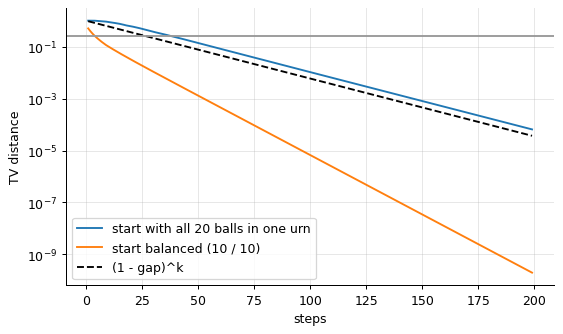

lazy Ehrenfest, N = 20: spectral gap 0.0500 (= 1/N), relaxation time 20, mixing time t_mix(1/4) = 39
  N =  10: t_mix =   16  (N log N / 2 = 12)
  N =  20: t_mix =   39  (N log N / 2 = 30)
  N =  40: t_mix =   91  (N log N / 2 = 74)
  N =  80: t_mix =  211  (N log N / 2 = 175)


In [4]:
eh = models.ehrenfest(20)
lazy = eh["lazy"]
ks = np.arange(1, 200)
pi_e = lazy.stationary()
tv = [0.5 * np.sum(np.abs(lazy.n_step(k)[0] - pi_e)) for k in ks]
tv_mid = [0.5 * np.sum(np.abs(lazy.n_step(k)[10] - pi_e)) for k in ks]
plt.semilogy(ks, tv, label="start with all 20 balls in one urn"); plt.semilogy(ks, tv_mid, label="start balanced (10 / 10)")
gap = lazy.spectral_gap()
plt.semilogy(ks, (1 - gap["gap"]) ** ks, "k--", label="(1 - gap)^k"); plt.axhline(0.25, color="0.6"); plt.legend(); plt.xlabel("steps"); plt.ylabel("TV distance"); plt.show()
print(f"lazy Ehrenfest, N = 20: spectral gap {gap['gap']:.4f} (= 1/N), relaxation time {gap['relaxation_time']:.0f}, mixing time t_mix(1/4) = {lazy.mixing_time(0.25)}")
for N in (10, 20, 40, 80):
    print(f"  N = {N:3d}: t_mix = {models.ehrenfest(N)['lazy'].mixing_time(0.25):4d}  (N log N / 2 = {N * np.log(N) / 2:.0f})")

Total-variation distance from π falls geometrically at the rate of the spectral gap, but the time to reach a
small distance also depends on the start: from the extreme state the walk needs about ½N log N steps (a
"cutoff": the distance stays near 1 and then drops abruptly), from the balanced state much less. The
relaxation time 1/gap = N understates the mixing time by the log factor. This is the arithmetic behind MCMC
burn-in.

## Reversibility and detailed balance

In [5]:
rows = []
for name, chain in (("Ehrenfest", eh["chain"]), ("random walk on a graph", mk.random_walk_on_graph(np.array([[0, 1, 1, 1], [1, 0, 1, 0], [1, 1, 0, 1], [1, 0, 1, 0]]))),
                    ("inventory (s, S)", c), ("cyclic drift 0 -> 1 -> 2", mk.MarkovChain([[0.1, 0.8, 0.1], [0.1, 0.1, 0.8], [0.8, 0.1, 0.1]]))):
    lam = chain.spectral_gap()["eigenvalues"]
    rows.append((name, chain.is_reversible(), bool(np.allclose(lam.imag, 0))))
print(pd.DataFrame(rows, columns=["chain", "reversible (detailed balance)", "real spectrum"]).to_string(index=False))

                   chain  reversible (detailed balance)  real spectrum
               Ehrenfest                           True           True
  random walk on a graph                           True           True
        inventory (s, S)                          False          False
cyclic drift 0 -> 1 -> 2                          False          False


A chain is reversible when π_i P_ij = π_j P_ji: in equilibrium the flow i → j equals the flow j → i, and a film
of the chain looks the same run backwards. Reversible chains have real spectra (P is similar to a symmetric
matrix); the cyclic chain circulates probability and has complex eigenvalues. Detailed balance is how MCMC
algorithms are *designed* (notebook 18): choose P so that it holds for the target π.

## PageRank

In [6]:
web = models.web_graph()
for d in (0.5, 0.85, 0.99):
    pr = mk.pagerank(web["adjacency"], d)
    print(f"damping {d}: " + ", ".join(f"{p} {v:.3f}" for p, v in sorted(zip(web["pages"], pr), key=lambda t: -t[1])))

damping 0.5: blog 0.209, pdf 0.184, shop 0.175, docs 0.166, home 0.133, about 0.132
damping 0.85: blog 0.227, pdf 0.202, shop 0.187, docs 0.162, home 0.118, about 0.104
damping 0.99: blog 0.233, pdf 0.210, shop 0.192, docs 0.159, home 0.113, about 0.092


PageRank is the stationary distribution of a surfer who follows a random link with probability d and jumps to
a random page otherwise; the jump makes the chain irreducible and aperiodic (and fixes the dangling PDF page).
As d → 1 the ranking concentrates on the pages the link structure traps the surfer in; the spectral gap is at
least 1 − d, which is why Google's power iteration converged in a few dozen steps on billions of pages.

## Inside the algorithm: mean first-passage times by a linear solve

In [7]:
Pm = inv["chain"].P; j = 0
others = [i for i in range(7) if i != j]
m = np.linalg.solve(np.eye(6) - Pm[np.ix_(others, others)], np.ones(6))      # m_i = 1 + sum_{k != j} P_ik m_k
print("by first-step analysis:", m.round(3), "\nfundamental matrix:  ", np.delete(M[:, 0], 0).round(3))

by first-step analysis: [9.287 9.287 6.971 8.184 8.807 9.287] 
fundamental matrix:   [9.287 9.287 6.971 8.184 8.807 9.287]


## Exercises
1. For the lazy random walk on a cycle of n vertices compute the mixing time t_mix(1/4) for n = 8..128 and show that it grows like n^2. Compare with the relaxation time 1/gap.
2. Find the stationary law of the (s, S) inventory chain for every s in 0..4 and S in s+1..10 with holding cost 1 per unit per week, lost sale cost 20 and ordering cost 15. Which policy minimises the long-run weekly cost?
3. **Implement it yourself:** write power iteration for PageRank on a sparse link list (dict of out-links), with dangling pages and damping, and reproduce `markov.pagerank` on the web graph.